In [3]:
import os
if not os.path.exists('tmdb-fetch'):
    !git clone https://github.com/ryuichi-github/info290-2026s-group5.git
    %cd info290-2026s-group5

In [4]:
import pandas as pd
df = pd.read_csv('tmdb-fetch/tmdb_movies.csv')
df.head(3)

,id,title,tagline,overview,release_date,genre_ids,genre_names,vote_average,vote_count,popularity,poster_path,backdrop_path,runtime,original_language,status,revenue,budget,belongs_to_collection
0,1236153,Mercy,Prove your innocence to an AI judge or face ex...,"In the near future, a detective stands on tria...",2026-01-20,"[878, 28, 53]","['Science Fiction', 'Action', 'Thriller']",7.109,522,452.1395,/pyok1kZJCfyuFapYXzHcy7BLlQa.jpg,/7HKpc11uQfxnw0Y8tRUYn1fsKqE.jpg,99,en,Released,49463290,60000000,False
1,1290821,Shelter,Her safety. His mission.,A man living in self-imposed exile on a remote...,2026-01-28,"[28, 80, 53]","['Action', 'Crime', 'Thriller']",7.009,107,429.6689,/buPFnHZ3xQy6vZEHxbHgL1Pc6CR.jpg,/6YjnTRBz704LF1uJ3ZC4wsS9T8r.jpg,107,en,Released,26786795,50000000,False
2,1272837,28 Years Later: The Bone Temple,Fear is the new faith.,Dr. Kelson finds himself in a shocking new rel...,2026-01-14,"[27, 53, 878]","['Horror', 'Thriller', 'Science Fiction']",7.195,635,195.1060,/kK1BGkG3KAvWB0WMV1DfOx9yTMZ.jpg,/hHDNOlATHhre4eZ7aYz5cdyJLik.jpg,109,en,Released,58586229,63000000,True


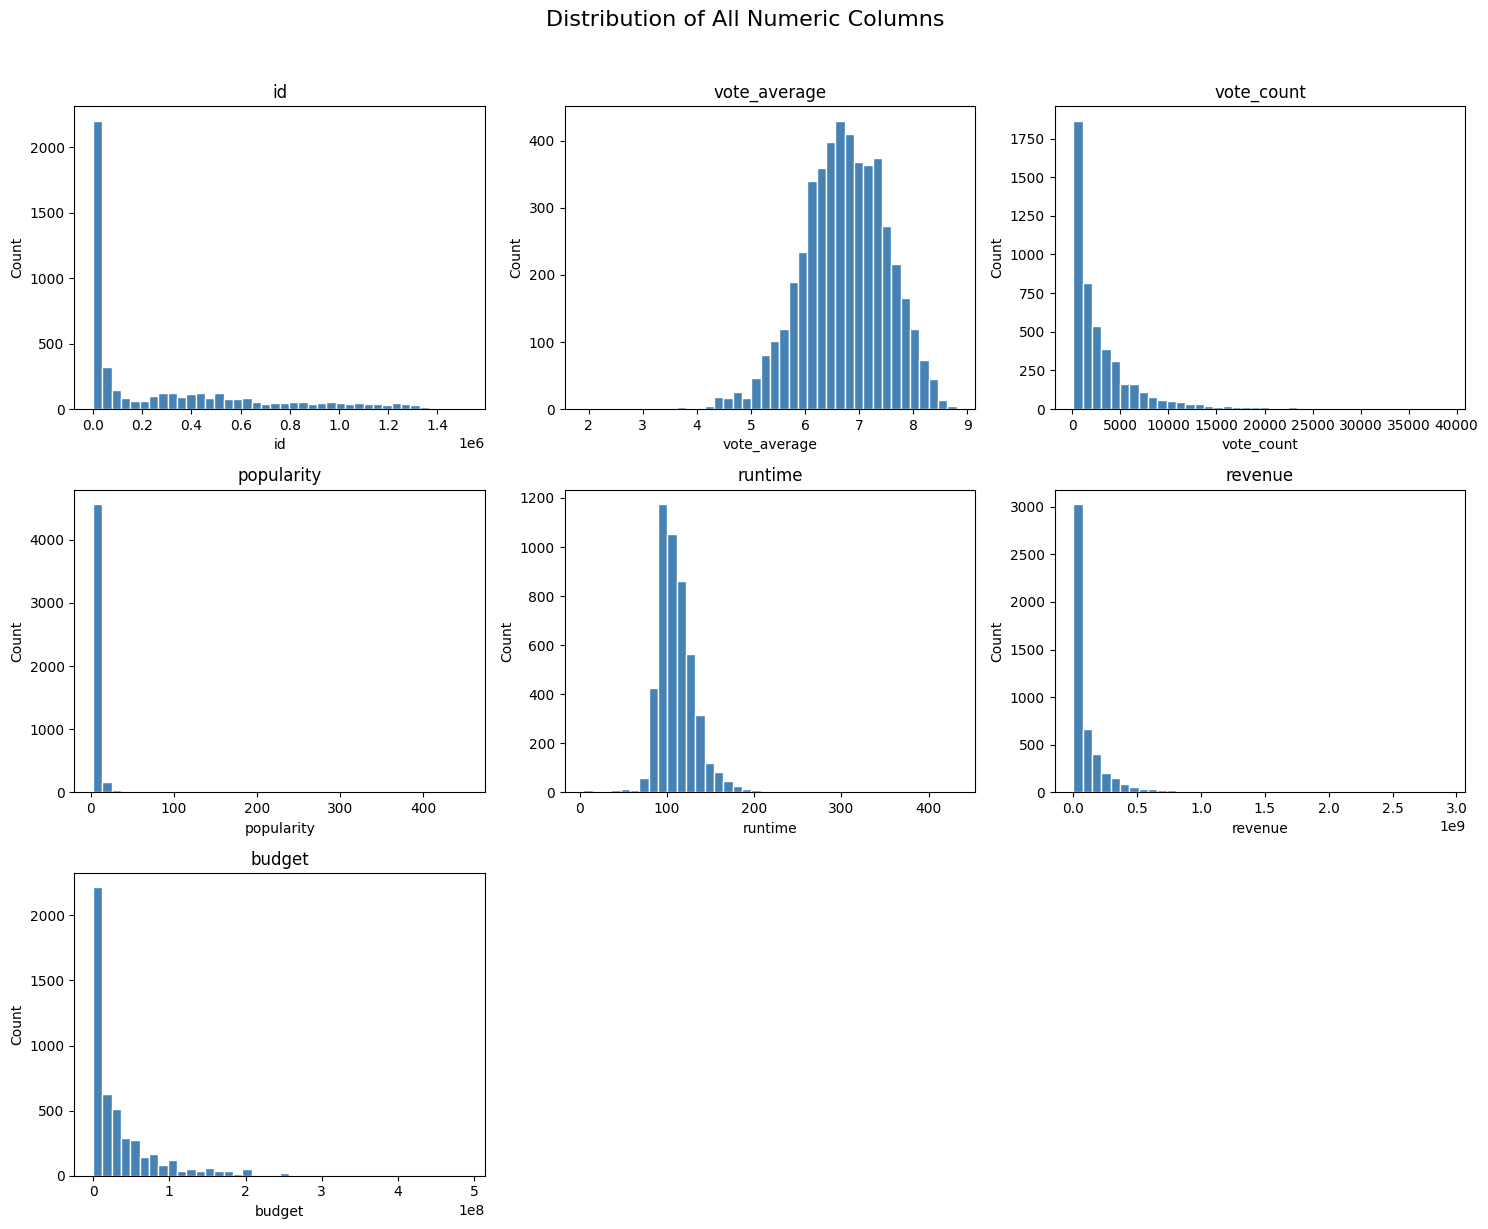

In [5]:
# histograms of the distributions over all columns individually
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns.tolist()

cols_per_row = 3
n_rows = -(-len(numeric_cols) // cols_per_row)  # ceiling division

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numeric Columns', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## OVERVIEW
# TMDB Corpus — Deep-Dive Analysis

This notebook characterises the 4,816-movie TMDB corpus underlying our RAG experiments. It moves from descriptive statistics through selection-bias diagnostics to a final synthesis explaining how the corpus shape constrains achievable RAG gains.

**Sections**
1. Selection-bias audit (filter funnel)
2. Temporal coverage & metadata completeness
3. Language bias
4. Genre composition & co-occurrence
5. Marketing surface — taglines and overviews
6. Audience signals — rating, popularity, vote count
7. Commercial bias — budget, revenue, ROI
8. Poster captions as marketing language
9. Bias profile of the typical RAG candidate
10. What is NOT in the corpus, and what it means for RAG

In [6]:
### STEP 0
### Setup and Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast, re
from collections import Counter
from itertools import combinations

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('tmdb-fetch/tmdb_movies.csv')
df['genre_list']   = df['genre_names'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['overview_len'] = df['overview'].fillna('').str.len()
df['tagline_len']  = df['tagline'].fillna('').str.len()
df['has_tagline']  = df['tagline'].fillna('').str.strip().astype(bool)
df['n_genres']     = df['genre_list'].apply(len)
df_ex = df.explode('genre_list')
print(df.shape)
df.head(3)

(4816, 24)


,id,title,tagline,overview,release_date,genre_ids,genre_names,vote_average,vote_count,popularity,poster_path,backdrop_path,runtime,original_language,status,revenue,budget,belongs_to_collection,genre_list,release_year,overview_len,tagline_len,has_tagline,n_genres
0,1236153,Mercy,Prove your innocence to an AI judge or face ex...,"In the near future, a detective stands on tria...",2026-01-20,"[878, 28, 53]","['Science Fiction', 'Action', 'Thriller']",7.109,522,452.1395,/pyok1kZJCfyuFapYXzHcy7BLlQa.jpg,/7HKpc11uQfxnw0Y8tRUYn1fsKqE.jpg,99,en,Released,49463290,60000000,False,"[Science Fiction, Action, Thriller]",2026,199,54,True,3
1,1290821,Shelter,Her safety. His mission.,A man living in self-imposed exile on a remote...,2026-01-28,"[28, 80, 53]","['Action', 'Crime', 'Thriller']",7.009,107,429.6689,/buPFnHZ3xQy6vZEHxbHgL1Pc6CR.jpg,/6YjnTRBz704LF1uJ3ZC4wsS9T8r.jpg,107,en,Released,26786795,50000000,False,"[Action, Crime, Thriller]",2026,205,24,True,3
2,1272837,28 Years Later: The Bone Temple,Fear is the new faith.,Dr. Kelson finds himself in a shocking new rel...,2026-01-14,"[27, 53, 878]","['Horror', 'Thriller', 'Science Fiction']",7.195,635,195.1060,/kK1BGkG3KAvWB0WMV1DfOx9yTMZ.jpg,/hHDNOlATHhre4eZ7aYz5cdyJLik.jpg,109,en,Released,58586229,63000000,True,"[Horror, Thriller, Science Fiction]",2026,199,22,True,3


## 1. Selection-bias audit - what survives the fetch funnel?

The fetch script (`tmdb-fetch/fetch_tmdb.py`) applies four hard filters: `vote_count >= 100`, `language=en-US`, `status=Released`, and `len(overview) >= 50`. Each filter selects a non-random slice of the global movie universe; quantifying their footprint here grounds every later interpretation.

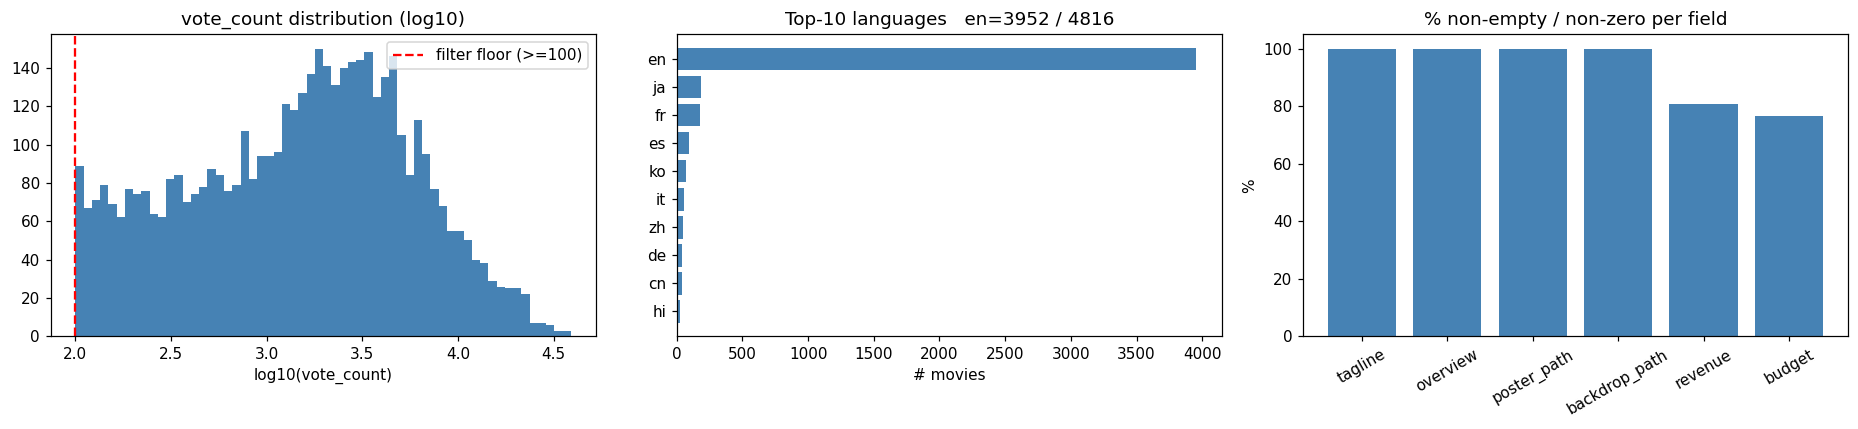

Field coverage:
  tagline        100.0%
  overview       100.0%
  poster_path    100.0%
  backdrop_path  100.0%
  revenue         80.7%
  budget          76.6%


[None, None, None, None, None, None]

In [7]:
### STEP 1
### filter footprint

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(np.log10(df['vote_count'].clip(lower=1)), bins=60, color='steelblue', edgecolor='none')
axes[0].axvline(np.log10(100), color='red', ls='--', label='filter floor (>=100)')
axes[0].set_title('vote_count distribution (log10)')
axes[0].set_xlabel('log10(vote_count)'); axes[0].legend()

lang = df['original_language'].value_counts()
axes[1].barh(lang.head(10).index[::-1], lang.head(10).values[::-1], color='steelblue')
axes[1].set_title(f'Top-10 languages   en={lang.iloc[0]} / {len(df)}')
axes[1].set_xlabel('# movies')

fields = ['tagline','overview','poster_path','backdrop_path','revenue','budget']
coverage = {f: (df[f].astype(bool) if df[f].dtype=='object' else (df[f]>0)).mean() for f in fields}
axes[2].bar(coverage.keys(), [v*100 for v in coverage.values()], color='steelblue')
axes[2].set_title('% non-empty / non-zero per field')
axes[2].set_ylabel('%'); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print('Field coverage:'); [print(f'  {k:14s} {v:6.1%}') for k,v in coverage.items()]

## 2. Temporal coverage & metadata completeness

A `popularity.desc` sort over-samples recent releases. Beyond a year histogram we plot per-decade rating and tagline-presence to see whether older films also enter the corpus with sparser metadata.

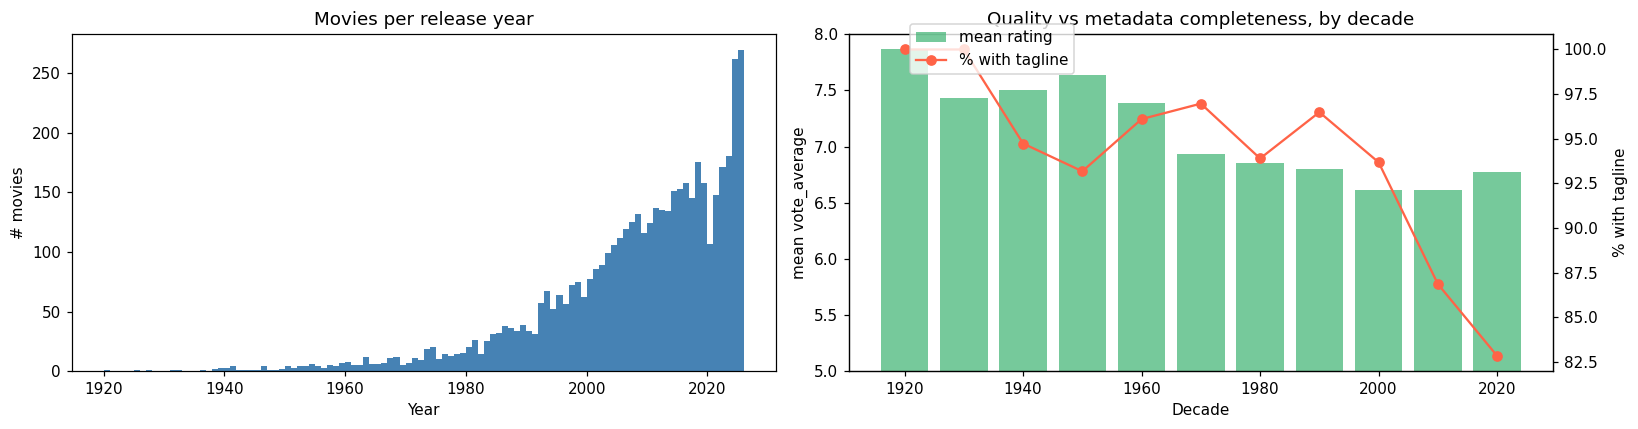

,n,mean_rating,median_overview,tagline_rate
decade,,,,
1920,3,7.868000,182.0,1.000000
1930,8,7.432250,275.0,1.000000
1940,19,7.505316,201.0,0.947368
1950,44,7.637977,232.5,0.931818
1960,77,7.385571,251.0,0.961039
1970,132,6.929735,213.5,0.969697
1980,295,6.856986,247.0,0.938983
1990,570,6.798856,276.5,0.964912
2000,1061,6.611016,278.0,0.936852


In [8]:
### STEP 2
### tempoarl

yr = df.dropna(subset=['release_year']).copy()
yr['decade'] = (yr['release_year'] // 10 * 10).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(yr['release_year'], bins=range(1920, 2027), color='steelblue', edgecolor='none')
axes[0].set_title('Movies per release year'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('# movies')

dec = yr.groupby('decade').agg(n=('id','size'),
                               mean_rating=('vote_average','mean'),
                               median_overview=('overview_len','median'),
                               tagline_rate=('has_tagline','mean'))
ax2 = axes[1]
ax2.bar(dec.index, dec['mean_rating'], width=8, color='mediumseagreen', alpha=0.7, label='mean rating')
ax2.set_ylabel('mean vote_average'); ax2.set_xlabel('Decade')
ax2.set_ylim(5, 8)
ax3 = ax2.twinx()
ax3.plot(dec.index, dec['tagline_rate']*100, color='tomato', marker='o', label='% with tagline')
ax3.set_ylabel('% with tagline')
ax2.set_title('Quality vs metadata completeness, by decade')
fig.legend(loc='upper left', bbox_to_anchor=(0.55, 0.95)); plt.tight_layout(); plt.show()
display(dec)

## 3. Language bias

The discover query is English-localised but TMDB still surfaces some non-English originals via popularity. We measure both the magnitude of English dominance and whether non-English titles in the corpus differ in rated quality.

,n,mean_rating,median_pop
original_language,,,
en,3952,6.659115,4.65705
ja,181,7.399083,4.26640
fr,176,6.618580,3.91430
es,93,6.963505,4.11120
ko,70,7.349129,5.01225
it,55,6.954909,4.20620
zh,46,7.101283,4.12315
de,42,6.894762,3.95195
cn,40,7.131300,4.03310


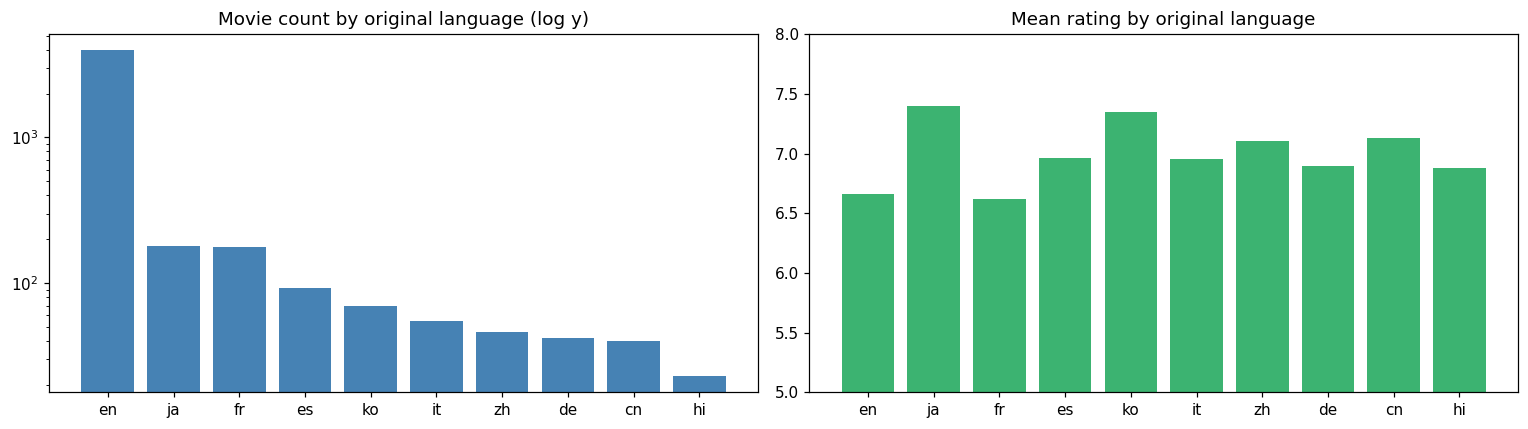

In [9]:
### STEP 3
### language

top_langs = df['original_language'].value_counts().head(10).index
sub = df[df['original_language'].isin(top_langs)].copy()
agg = (sub.groupby('original_language')
           .agg(n=('id','size'),
                mean_rating=('vote_average','mean'),
                median_pop=('popularity','median'))
           .sort_values('n', ascending=False))
display(agg)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(agg.index, agg['n'], color='steelblue'); axes[0].set_yscale('log')
axes[0].set_title('Movie count by original language (log y)')
axes[1].bar(agg.index, agg['mean_rating'], color='mediumseagreen')
axes[1].set_title('Mean rating by original language'); axes[1].set_ylim(5, 8)
plt.tight_layout(); plt.show()

## 4. Genre composition & co-occurrence

Movies are multi-labelled (mean ~2 genres each). Beyond raw counts, the *pairings* reveal latent structure: Action+Thriller, Drama+Romance, Comedy+Romance bundles dominate.

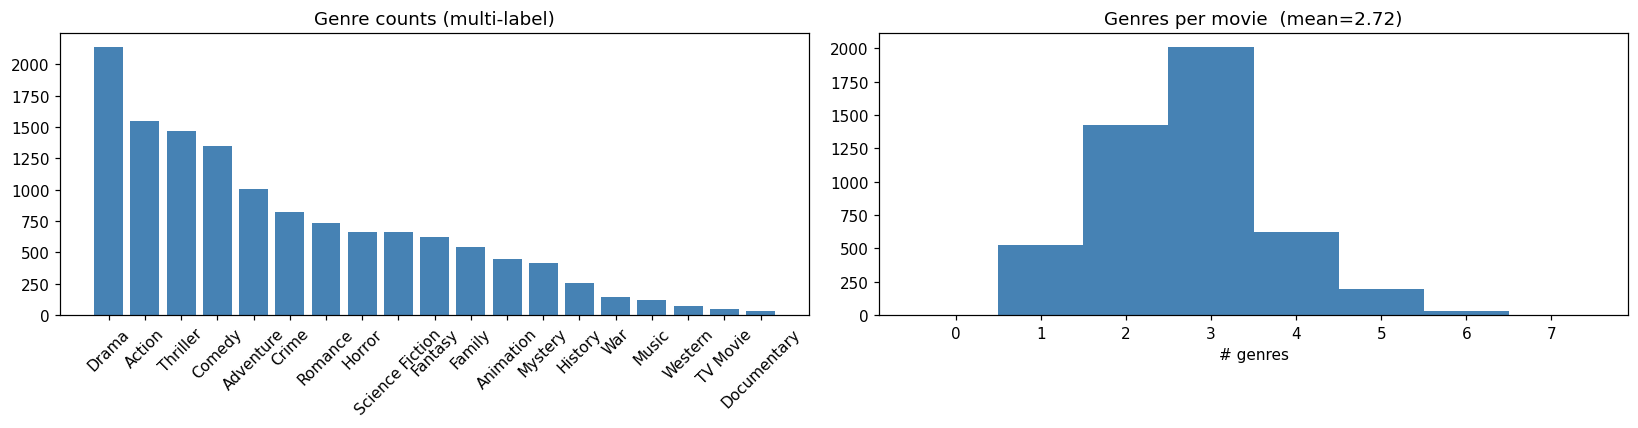

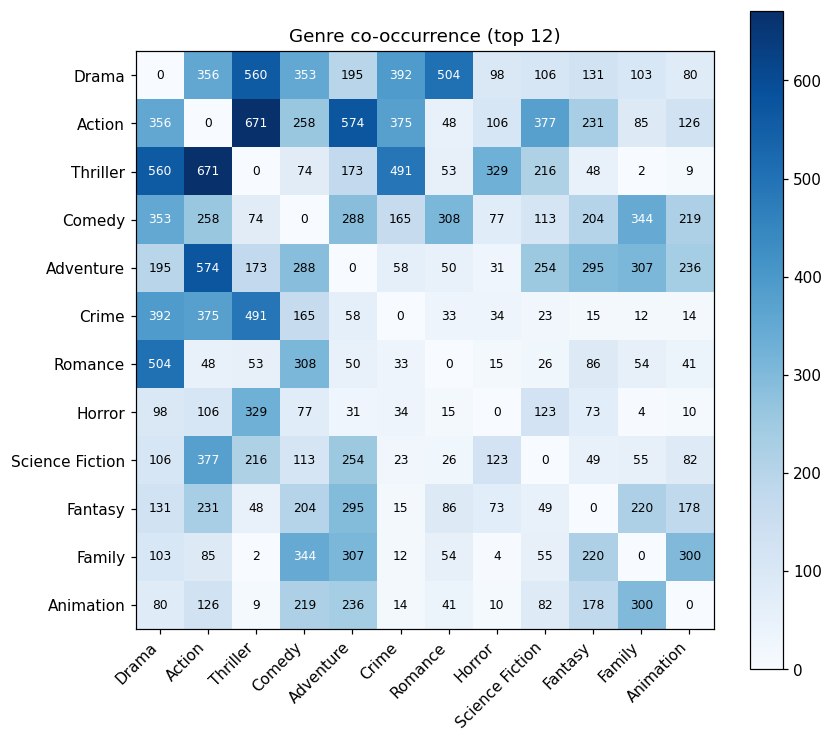

In [10]:
### STEP 4
### genre + co-occurrence

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
gc = df_ex['genre_list'].value_counts()
axes[0].bar(gc.index, gc.values, color='steelblue'); axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Genre counts (multi-label)')

axes[1].hist(df['n_genres'], bins=range(0, df['n_genres'].max()+2), color='steelblue', align='left')
axes[1].set_title(f'Genres per movie  (mean={df["n_genres"].mean():.2f})')
axes[1].set_xlabel('# genres')
plt.tight_layout(); plt.show()

genres_top = gc.head(12).index.tolist()
co = pd.DataFrame(0, index=genres_top, columns=genres_top)
for gl in df['genre_list']:
    pairs = [g for g in gl if g in genres_top]
    for a, b in combinations(pairs, 2):
        co.loc[a, b] += 1; co.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(co.values, cmap='Blues')
ax.set_xticks(range(len(genres_top))); ax.set_xticklabels(genres_top, rotation=45, ha='right')
ax.set_yticks(range(len(genres_top))); ax.set_yticklabels(genres_top)
for i in range(len(genres_top)):
    for j in range(len(genres_top)):
        ax.text(j, i, int(co.iloc[i, j]), ha='center', va='center', fontsize=8,
                color='white' if co.iloc[i, j] > co.values.max()/2 else 'black')
ax.set_title('Genre co-occurrence (top 12)')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 5. Marketing surface — taglines and overviews

Taglines and overviews are the actual texts our RAG pipeline embeds. Their length, presence rate, and stylistic patterns shape what the retriever can match on — and reveal genre-specific marketing voice.

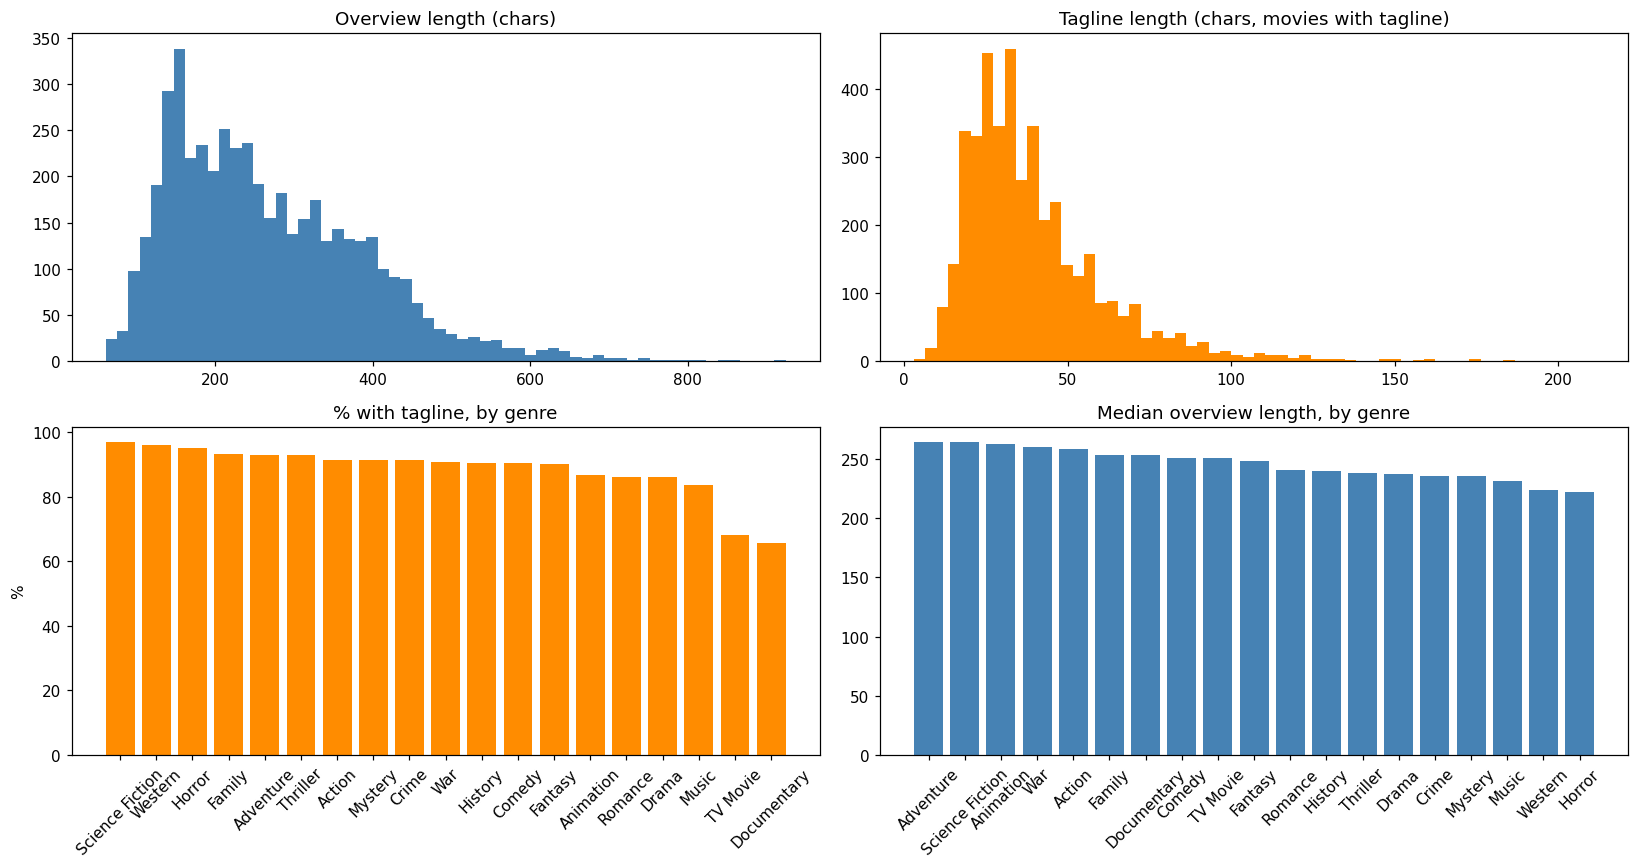

Taglines ending '?' : 4.6%
Taglines ending '!' : 6.6%
Mean word count     : 7.4

Most common opening words:
tagline
the      509
a        218
you       76
they      75
when      73
it's      72
there     69
in        69
this      65
what      63
some      62
no        62
every     59
it        57
one       57
Name: count, dtype: int64


In [11]:
### STEP 5
### text marketing

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

axes[0,0].hist(df['overview_len'].dropna(), bins=60, color='steelblue', edgecolor='none')
axes[0,0].set_title('Overview length (chars)')
axes[0,1].hist(df.loc[df['has_tagline'], 'tagline_len'], bins=60, color='darkorange', edgecolor='none')
axes[0,1].set_title('Tagline length (chars, movies with tagline)')

tr = df_ex.groupby('genre_list')['has_tagline'].mean().sort_values(ascending=False)
axes[1,0].bar(tr.index, tr.values*100, color='darkorange')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('% with tagline, by genre'); axes[1,0].set_ylabel('%')

om = df_ex.groupby('genre_list')['overview_len'].median().sort_values(ascending=False)
axes[1,1].bar(om.index, om.values, color='steelblue')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_title('Median overview length, by genre')
plt.tight_layout(); plt.show()

tg = df.loc[df['has_tagline'], 'tagline']
print(f"Taglines ending '?' : {(tg.str.strip().str.endswith('?')).mean():.1%}")
print(f"Taglines ending '!' : {(tg.str.strip().str.endswith('!')).mean():.1%}")
print(f"Mean word count     : {tg.str.split().str.len().mean():.1f}")
opening = tg.str.split().str[0].str.lower().value_counts().head(15)
print('\nMost common opening words:'); print(opening)

## 6. Audience signals — rating, popularity, vote count

Is popularity a proxy for quality? Spoiler: only weakly. The shape of the relationship — and the rating ceiling effect — matter more than the headline correlation.

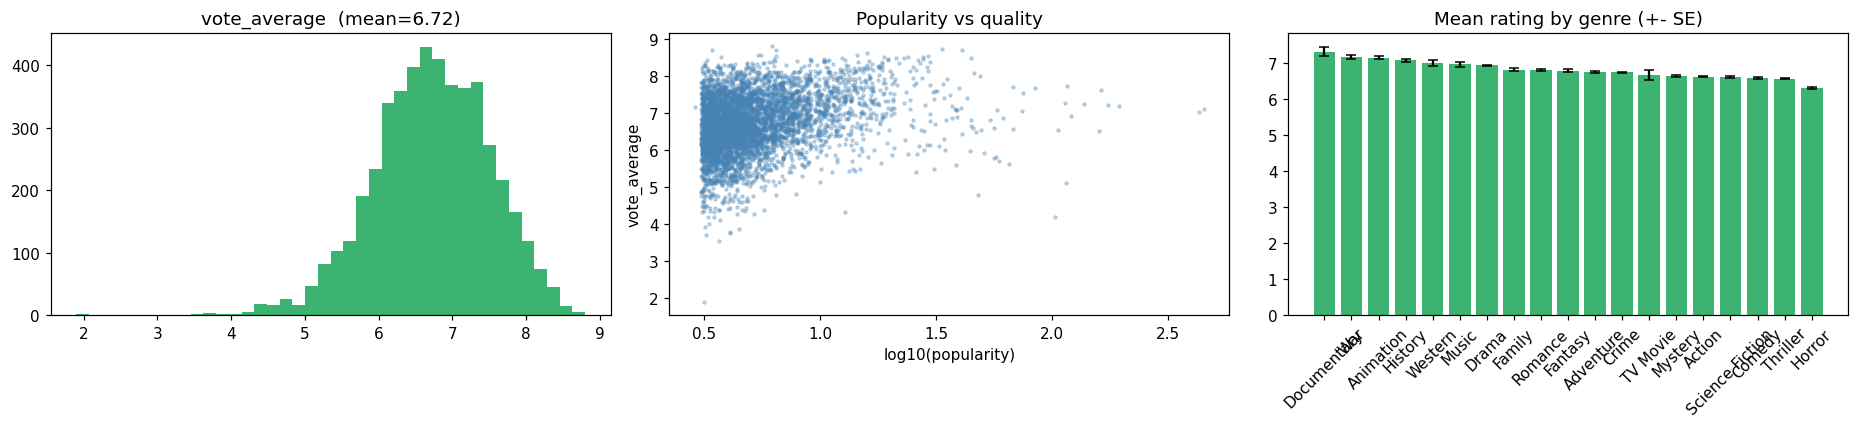

Pearson(popularity, vote_average) = 0.098


In [12]:
### Step 6
### audience

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(df['vote_average'], bins=40, color='mediumseagreen', edgecolor='none')
axes[0].set_title(f'vote_average  (mean={df.vote_average.mean():.2f})')

axes[1].scatter(np.log10(df['popularity'].clip(lower=0.1)), df['vote_average'],
                s=4, alpha=0.3, color='steelblue')
axes[1].set_xlabel('log10(popularity)'); axes[1].set_ylabel('vote_average')
axes[1].set_title('Popularity vs quality')

gr = (df_ex.groupby('genre_list')
            .agg(mean=('vote_average','mean'), std=('vote_average','std'), n=('id','size'))
            .sort_values('mean', ascending=False))
axes[2].bar(gr.index, gr['mean'], yerr=gr['std']/np.sqrt(gr['n']),
            color='mediumseagreen', capsize=3)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Mean rating by genre (+- SE)')
plt.tight_layout(); plt.show()
print(f"Pearson(popularity, vote_average) = {df[['popularity','vote_average']].corr().iloc[0,1]:.3f}")

## 7. Commercial bias — budget, revenue, ROI

Budget and revenue are user-contributed TMDB fields with extreme missingness. The completeness pattern is itself the finding: financial coverage skews toward big-studio releases, distorting any ROI claim.

Has revenue >0: 80.7%
Has budget  >0: 76.6%
Has both    >0: 71.9%


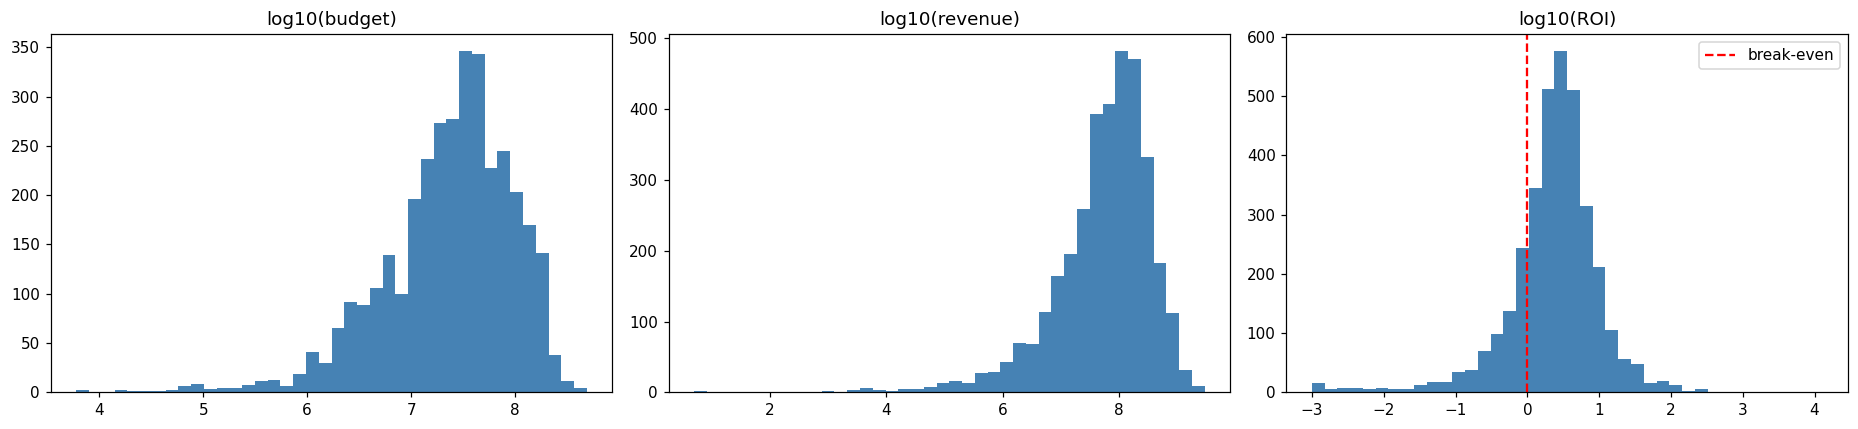

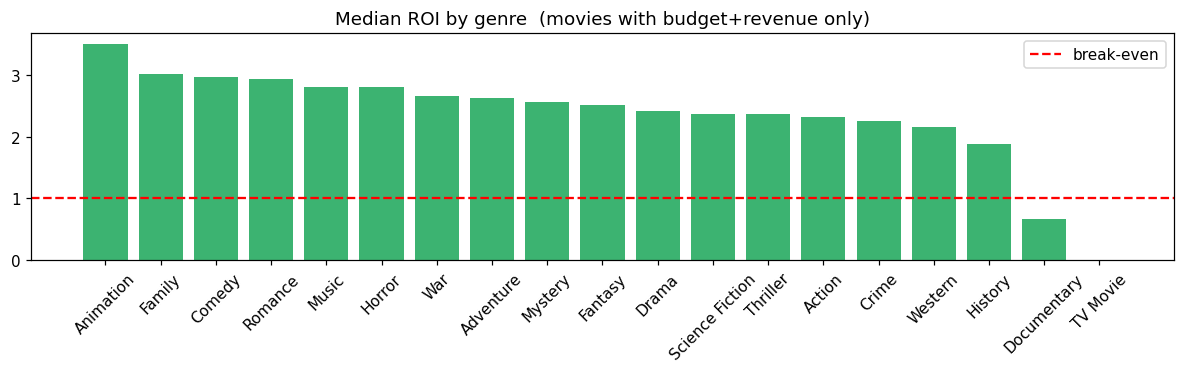

In [13]:
### STEP 7
### commercial

print('Has revenue >0:', f"{(df.revenue>0).mean():.1%}")
print('Has budget  >0:', f"{(df.budget>0).mean():.1%}")
print('Has both    >0:', f"{((df.revenue>0) & (df.budget>0)).mean():.1%}")

fin = df[(df.revenue>0) & (df.budget>0)].copy()
fin['roi'] = fin['revenue'] / fin['budget']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(np.log10(fin['budget']),  bins=40, color='steelblue', edgecolor='none'); axes[0].set_title('log10(budget)')
axes[1].hist(np.log10(fin['revenue']), bins=40, color='steelblue', edgecolor='none'); axes[1].set_title('log10(revenue)')
axes[2].hist(np.log10(fin['roi'].clip(lower=0.001)), bins=40, color='steelblue', edgecolor='none')
axes[2].axvline(0, color='red', ls='--', label='break-even'); axes[2].set_title('log10(ROI)'); axes[2].legend()
plt.tight_layout(); plt.show()

fin_ex = fin.explode('genre_list')
roi_by_g = fin_ex.groupby('genre_list')['roi'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(roi_by_g.index, roi_by_g.values, color='mediumseagreen')
ax.axhline(1, color='red', ls='--', label='break-even')
ax.tick_params(axis='x', rotation=45)
ax.set_title('Median ROI by genre  (movies with budget+revenue only)')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Poster captions as marketing language

`poster_captions.csv` (47k AI-generated descriptions of TMDB posters) lets us probe the *visual* marketing surface. We compute distinctive vocabulary per genre vs the corpus baseline — what a horror poster *depicts* differs sharply from what a romance poster depicts.

Captions joined: 4,312   mean length 3755 chars


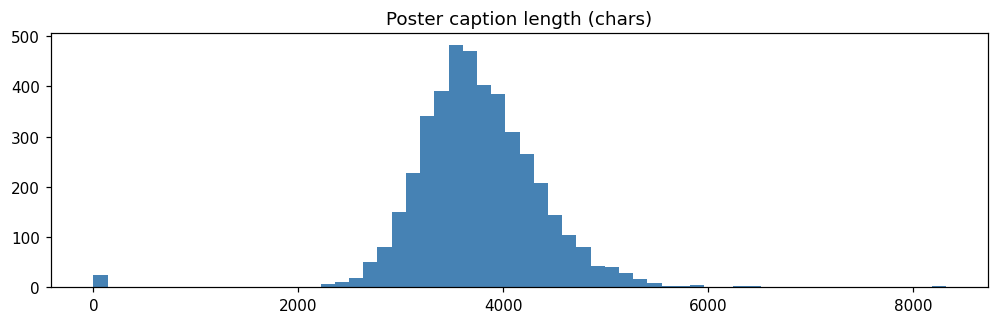


Top 10 distinctive words per genre  (relative to corpus baseline):

  Drama        ['bittersweet', 'karate', 'wistful', 'political', "ape's", 'mentorship', 'legal', 'boxing', 'bench', 'perseverance']

  Action       ['martial', "bond's", 'chan', 'saiyan', 'ninja', "goku's", 'arts', "batman's", 'indiana', 'goku']

  Thriller     ["bond's", 'terminator', "rambo's", 'wick', 'lethal', "statham's", 'targeting', 'liam', "neeson's", 'willis']

  Comedy       ['comedic', 'comedy', 'comically', 'entertaining', 'lego', 'bewildered', 'spongebob', 'humorous', 'mischief', 'parody']

  Adventure    ['pok', 'spongebob', 'indiana', 'lightsaber', 'superman', 'karate', "na'vi", 'mewtwo', "superman's", 'pikachu']

  Crime        ['holmes', 'ace', 'heist', "statham's", 'crime', 'austin', "washington's", 'illicit', 'handcuffs', 'denzel']

  Science Fiction ['godzilla', "robot's", 'saiyan', 'spacecraft', 'terminator', "na'vi", 'extraterrestrial', 'resident', "alien's", 'hulk']

  Horror       ['zombie', 'c

In [14]:
### STEP 8
### poster captions

caps = pd.read_csv('tmdb-fetch/poster_captions.csv')
caps = caps.merge(df[['id','genre_list']], on='id', how='inner')
caps['cap_len'] = caps['poster_caption'].fillna('').str.len()
print(f'Captions joined: {len(caps):,}   mean length {caps.cap_len.mean():.0f} chars')

fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(caps['cap_len'].dropna(), bins=60, color='steelblue', edgecolor='none')
ax.set_title('Poster caption length (chars)'); plt.show()

STOP = set('the a an of and to in on for with is it from this that as by at one his her their our he she they we you i be was are were has have had not no or but so if then there here image picture shows showing scene poster movie film'.split())
def tokens(s):
    return [w for w in re.findall(r"[a-z']{3,}", str(s).lower()) if w not in STOP]

caps_ex = caps.explode('genre_list').dropna(subset=['genre_list'])
top_genres = caps_ex['genre_list'].value_counts().head(8).index.tolist()

baseline = Counter()
for s in caps['poster_caption'].dropna():
    baseline.update(tokens(s))
total_b = sum(baseline.values())

print('\nTop 10 distinctive words per genre  (relative to corpus baseline):')
for g in top_genres:
    sub = Counter()
    for s in caps_ex.loc[caps_ex['genre_list']==g, 'poster_caption'].dropna():
        sub.update(tokens(s))
    total_s = sum(sub.values())
    scored = sorted(((w, (c/total_s) / ((baseline[w]+1)/total_b))
                     for w, c in sub.items() if c >= 20),
                    key=lambda x: -x[1])[:10]
    print(f'\n  {g:12s} {[w for w,_ in scored]}')

## 9. Bias profile of the typical RAG retrieval candidate

We split the corpus at the median `vote_count` to compare "well-known within corpus" vs "long-tail within corpus". This is a within-corpus contrast — *both halves are already pre-filtered for popularity globally* — but it gives a directional read on what a retriever would surface.

,n,mean_rating,median_year,median_pop,has_revenue,mean_overview_len
tier,,,,,,
long-tail (within corpus),2408,6.511948,2014.0,3.9480,0.651993,263.424003
well-known,2408,6.936230,2010.0,5.5696,0.961794,273.261213


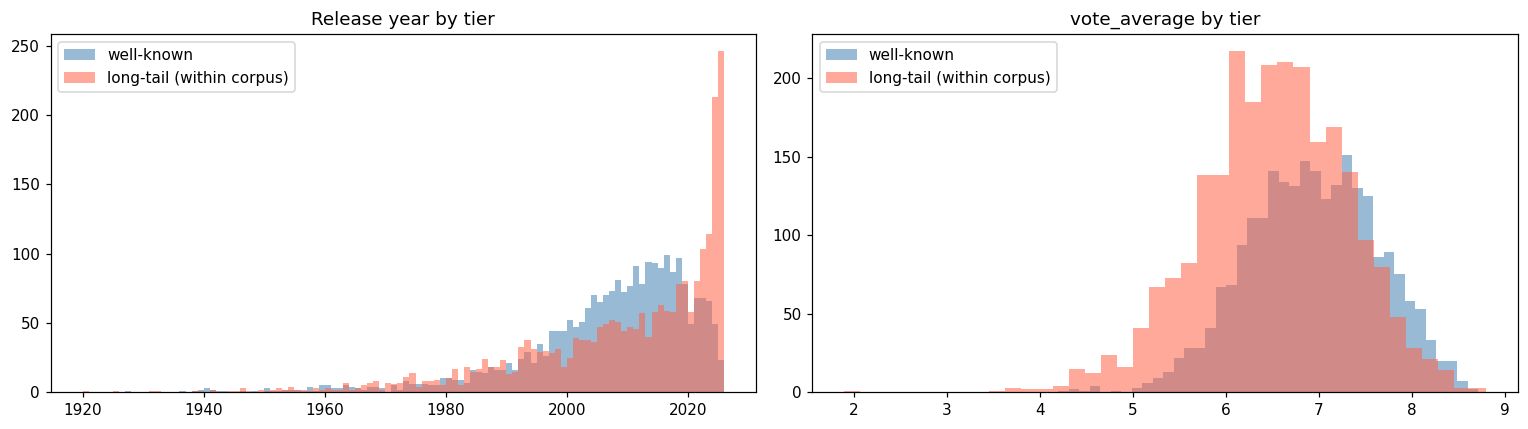

In [15]:
### Step 9
### tier comparison

median_vc = df['vote_count'].median()
df['tier'] = np.where(df['vote_count'] >= median_vc, 'well-known', 'long-tail (within corpus)')
profile = (df.groupby('tier')
             .agg(n=('id','size'),
                  mean_rating=('vote_average','mean'),
                  median_year=('release_year','median'),
                  median_pop=('popularity','median'),
                  has_revenue=('revenue', lambda s: (s>0).mean()),
                  mean_overview_len=('overview_len','mean')))
display(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for tier, color in [('well-known','steelblue'), ('long-tail (within corpus)','tomato')]:
    s = df.loc[df['tier']==tier, 'release_year'].dropna()
    axes[0].hist(s, bins=range(1920, 2027), alpha=0.55, label=tier, color=color)
axes[0].set_title('Release year by tier'); axes[0].legend()

for tier, color in [('well-known','steelblue'), ('long-tail (within corpus)','tomato')]:
    s = df.loc[df['tier']==tier, 'vote_average'].dropna()
    axes[1].hist(s, bins=40, alpha=0.55, label=tier, color=color)
axes[1].set_title('vote_average by tier'); axes[1].legend()
plt.tight_layout(); plt.show()

## SYNTHESIS
## 10. What is NOT in the corpus, and what it means for RAG

**Available in TMDB**: title, tagline, overview, genres, release date, budget/revenue (sparse), aggregate audience rating, popularity score, posters.

**Not available** (relevant to a marketing-RAG paper, worth flagging as limitations):
- Voter demographics — age, gender, ethnicity, country of voters.
- Marketing spend, ad placements, trailer view counts, social-media reach.
- Critical reviews (Rotten Tomatoes, Metacritic) — only one user-aggregated score exists here.
- Box-office geography and theatrical-window data.
- Audience-segmented sentiment.

**The bias chain that likely explains weak RAG gains**:
1. `vote_count >= 100` floor — rejects niche / cult / festival films, exactly the regime where RAG would add the most marginal information.
2. `language=en-US` discover query — corpus is overwhelmingly English (~90%+), the slice an LLM was trained on most heavily.
3. `popularity.desc` sort — over-samples canonical, much-discussed titles (Marvel, Disney, large franchises).
4. Required `len(overview) >= 50` — biases toward films with marketing departments writing studio copy.
5. The retrieved overviews and taglines are *promotional copy* the LLM has very likely seen during pre-training (TMDB scrapes are common in public crawls).

**Implication**: this corpus is structurally a *unideal case* for measuring marginal RAG benefit. Every retrieval candidate is content the base model already has dense, redundant knowledge of. To stress-test RAG meaningfully one would need an axis where retrieval truly adds *new* signal — segmented critical reviews, post-training releases, or non-English / festival-circuit films absent from common training crawls.

The poster-caption analysis (§8) is a partial exception: AI-generated visual descriptions are *not* in standard pre-training corpora, so retrieval over poster captions is the part of the pipeline most likely to provide non-redundant signal — a hypothesis worth testing in future ablations.